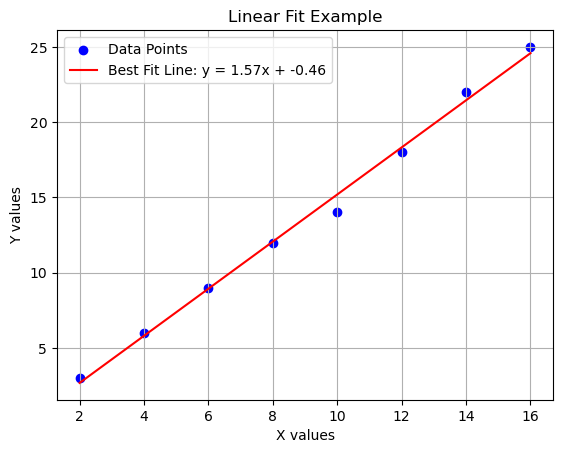

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Define new data points
x = np.array([2, 4, 6, 8, 10, 12, 14, 16])
y = np.array([3, 6, 9, 12, 14, 18, 22, 25])

# Find the best fit
a, b = np.polyfit(x, y, 1)

plt.scatter(x, y, label="Data Points", color='blue')

 
plt.plot(x, a*x + b, color='red', label=f"Best Fit Line: y = {a:.2f}x + {b:.2f}")

plt.xlabel("X values")
plt.ylabel("Y values")
plt.title("Linear Fit Example")
plt.legend()
plt.grid(True)

# Plot
plt.show()  


[-2.07063938  0.573119  ]


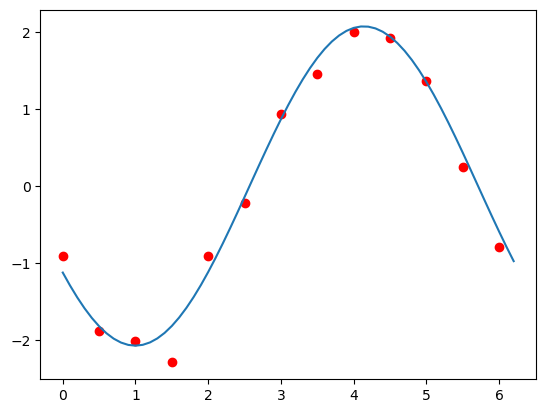

In [6]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
start = 0
stop = 2*np.pi
increment = 0.5
x = np.arange(start,stop,increment)
a = 2
b = 10
np.random.seed()
y_noise = 0.2 * np.random.normal(size=x.size)
y = a * np.sin(x + b)
y = y + y_noise
plt.plot(x,y, 'or')
def model(x, a, b):
    y = a * np.sin(x + b)
    return y
popt, pcov = curve_fit(model, x, y)
print(popt)
increment = 0.1
xmodeldata = np.arange(start,stop,increment)
ymodel = model(xmodeldata, *popt)
plt.plot(xmodeldata,ymodel)


Fitted parameters: [-2.02627181  0.55862538]


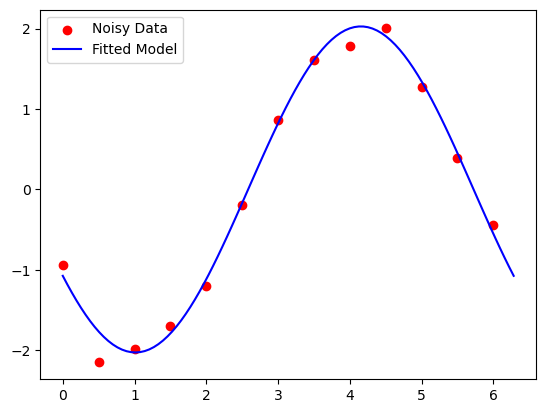

In [7]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# Define range and increment
start, stop = 0, 2 * np.pi
increment = 0.5
x = np.arange(start, stop, increment)

# Define true parameters
a_true, b_true = 2, 10

# Generate noisy data
np.random.seed(None)  # Ensures randomization
y_noise = 0.2 * np.random.normal(size=x.size)
y = a_true * np.sin(x + b_true) + y_noise

# Plot raw data
plt.scatter(x, y, color='red', label="Noisy Data")

# Define the model function
def model(x, a, b):
    return a * np.sin(x + b)

# Perform curve fitting
popt, _ = curve_fit(model, x, y, p0=[1, 1])  # Initial guesses for better convergence
print("Fitted parameters:", popt)

# Generate smooth model curve
xmodeldata = np.linspace(start, stop, 100)  # Higher resolution for a smoother curve
ymodel = model(xmodeldata, *popt)

# Plot fitted model
plt.plot(xmodeldata, ymodel, label="Fitted Model", color='blue')
plt.legend()
plt.show()


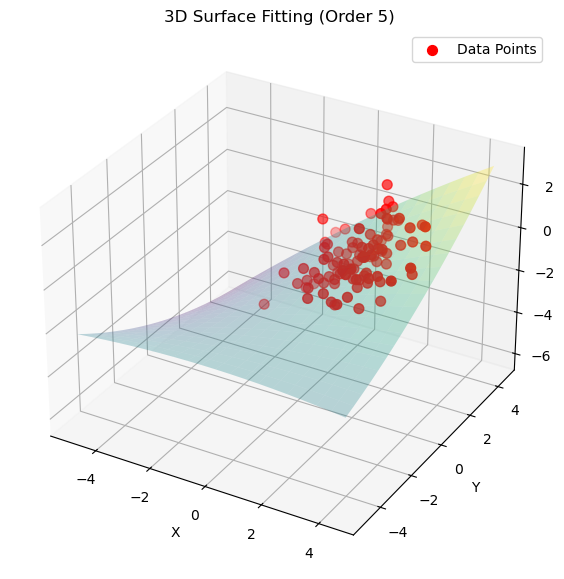

In [2]:
#3D surface fitting
import numpy as np
import scipy.linalg
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def generate_data(num_points=100):
    """Generate random 3D data points with a given mean and covariance."""
    mean = np.array([1.0, 2.0, -1.0])
    cov = np.array([[1.2, -0.3, 0.7], [-0.3, 1.0, 0.2], [0.7, 0.2, 1.1]])
    data = np.random.multivariate_normal(mean, cov, num_points)
    data[:, 1] = np.abs(data[:, 1])  # Ensure positive Y values
    return data

def fit_surface(data, order=2):
    """Fit a polynomial surface to the given data."""
    X, Y, Z = data[:, 0], data[:, 1], data[:, 2]
    terms = {
        1: lambda x, y: np.c_[x, y, np.ones_like(x)],
        2: lambda x, y: np.c_[np.ones_like(x), x, y, x*y, x**2, y**2],
        3: lambda x, y: np.c_[np.ones_like(x), x, y, x*y, x**2, y**2, x**3, y**3]
    }
    A = terms[order](X, Y)
    C, _, _, _ = scipy.linalg.lstsq(A, Z)
    return C, terms[order]

def plot_surface(data, coeffs, basis_function, grid_size=5):
    """Plot the fitted surface along with the original data points."""
    X_grid, Y_grid = np.meshgrid(np.arange(-grid_size, grid_size, 0.5), 
                                 np.arange(-grid_size, grid_size, 0.5))
    XX, YY = X_grid.flatten(), Y_grid.flatten()
    Z_grid = np.dot(basis_function(XX, YY), coeffs).reshape(X_grid.shape)
    
    fig = plt.figure(figsize=(10, 7))
    axs = fig.add_subplot(111, projection='3d')
    axs.plot_surface(X_grid, Y_grid, Z_grid, rstride=1, cstride=1, alpha=0.3, cmap='viridis')
    axs.scatter(data[:, 0], data[:, 1], data[:, 2], c='r', s=50, label='Data Points')
    
    axs.set_xlabel('X')
    axs.set_ylabel('Y')
    axs.set_zlabel('Z')
    axs.set_title(f'3D Surface Fitting (Order {len(coeffs) - 1})')
    axs.legend()
    plt.show()

# Run fitting and visualization
data = generate_data()
order = 2  # Choose 1 (linear), 2 (quadratic), or 3 (cubic)
coeffs, basis_function = fit_surface(data, order)
plot_surface(data, coeffs, basis_function)


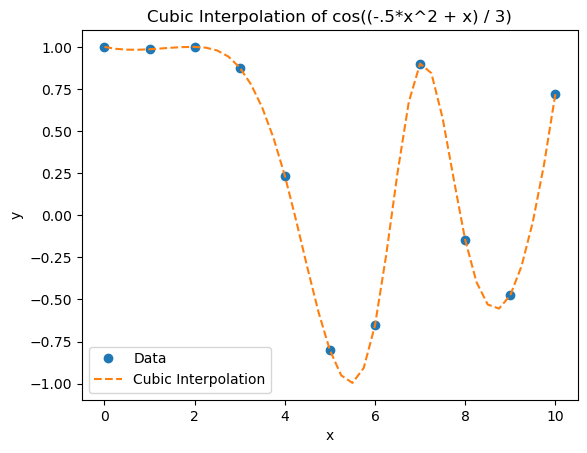

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# Define data points
x = np.linspace(0, 10, num=11, endpoint=True)
y = np.cos((-.5 * x**2 + x) / 3)

# Create cubic interpolation function
f_cubic = interp1d(x, y, kind='cubic')

# Define new x values for interpolation
xnew = np.linspace(0, 10, num=41, endpoint=True)

# Plot the results
plt.plot(x, y, 'o', label="Data")
plt.plot(xnew, f_cubic(xnew), '--', label="Cubic Interpolation")

# Labels and legend
plt.xlabel("x")
plt.ylabel("y")
plt.legend(loc='best')
plt.title("Cubic Interpolation of cos((-.5*x^2 + x) / 3)")

# Show plot
plt.show()


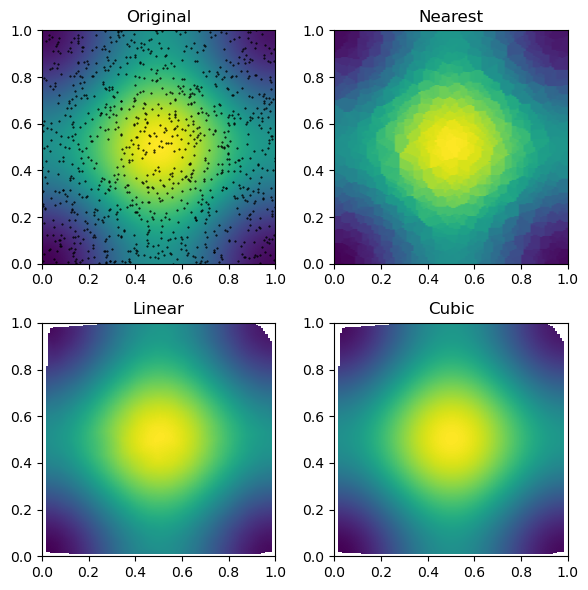

In [3]:
import numpy as np
import scipy.linalg
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

def func(x, y):
    """2D function for interpolation."""
    PI = 3.14
    return 20 + x**2 + y**2 - 10 * (np.cos(2 * PI * x) + np.cos(2 * PI * y))

# Create grid and data points
grid_x, grid_y = np.mgrid[0:1:100j, 0:1:200j]
points = np.random.rand(1000, 2)
values = func(points[:, 0], points[:, 1])

# Interpolation methods
methods = ['nearest', 'linear', 'cubic']
grids = {method: griddata(points, values, (grid_x, grid_y), method=method) for method in methods}

# Plot results
fig, axes = plt.subplots(2, 2, figsize=(6, 6))
axes = axes.flatten()

titles = ['Original', 'Nearest', 'Linear', 'Cubic']
data_list = [func(grid_x, grid_y)] + [grids[method] for method in methods]

for ax, data, title in zip(axes, data_list, titles):
    ax.imshow(data.T, extent=(0, 1, 0, 1), origin='lower')
    ax.set_title(title)
    if title == 'Original':
        ax.plot(points[:, 0], points[:, 1], 'k.', ms=1)

plt.tight_layout()
plt.show()
